In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr
import duckdb as db
import matplotlib.pyplot as plt


In [3]:
conn = db.connect('main.db')

In [3]:
path_to_datasets = "C://Users//HP//OneDrive//Desktop//AB Test Analysis Project"
conn.execute(f"""
            CREATE TABLE IF NOT EXISTS sessions AS 
            SELECT * FROM read_csv('{path_to_datasets}/sessions_data.csv')
             """)

conn.execute("SELECT * FROM sessions LIMIT 3").fetch_df()

,session_id,user_id,variant,device_type,user_type,session_date,session_duration_seconds,pages_viewed,time_on_pdp_seconds,bounce_rate,cart_action
0,100000,50000,A,desktop,new,2024-10-01 11:14:08,215.76,2,79.99,0,none
1,100001,50000,A,mobile,returning,2024-10-01 07:37:27,205.59,4,92.24,0,none
2,100002,50001,A,desktop,new,2024-10-01 05:32:38,197.42,1,60.44,0,abandoned


In [4]:
conn.execute(f"""
            CREATE TABLE IF NOT EXISTS conversions AS 
            SELECT * FROM read_csv('{path_to_datasets}/conversions_data.csv')
             """)

conn.execute("SELECT * FROM conversions LIMIT 3").fetch_df()

,session_id,order_id,variant,device_type,user_type,product_category,order_value_eur,products_in_order,conversion_time_hours
0,100014,ORD200000,B,tablet,returning,lighting,64.98,1,13.54
1,100015,ORD200001,A,desktop,new,sofa,1571.68,1,30.22
2,100025,ORD200002,B,tablet,returning,sofa,680.39,1,16.06


In [5]:
df = conn.execute("SELECT * FROM conversions").fetch_df()

df.describe()

,session_id,order_value_eur,products_in_order,conversion_time_hours
count,8572.000000,8572.000000,8572.000000,8572.000000
mean,193492.903406,836.758919,1.355926,19.007911
std,54282.510160,670.621475,0.577761,20.572587
min,100014.000000,23.541000,1.000000,0.000000
25%,146008.250000,223.006875,1.000000,4.917500
50%,193667.000000,718.447000,1.000000,12.540000
75%,240356.000000,1222.927500,2.000000,25.700000
max,287946.000000,2500.000000,3.000000,168.000000


In [6]:
conn.execute(f"""
            CREATE TABLE IF NOT EXISTS engagement AS 
            SELECT * FROM read_csv('{path_to_datasets}/engagement_data.csv')
             """)

conn.execute("SELECT * FROM engagement LIMIT 3").fetch_df()

,session_id,variant,images_viewed,max_scroll_depth_pct,cta_clicks,wishlist_saves,cross_sell_clicks,spec_table_views_seconds
0,100000,A,3,27,0,0,0,33
1,100001,A,1,83,1,0,0,25
2,100002,A,1,52,0,0,0,13


### Phase 1: Establish Baseline
- What's the overall conversion rate for A vs B?
- What's the average order value for A vs B?
- What's the revenue per session for each variant?
- Are sample sizes sufficient for significance?

In [5]:
conn.execute("""
            WITH base_metrics AS (
    SELECT
        s.variant,
        COUNT(s.session_id) AS total_sessions,
        ROUND(SUM(CASE WHEN s.cart_action = 'purchased' THEN 1 ELSE 0 END) * 100.0 / COUNT(s.session_id), 2) AS conversion_rate,
        ROUND(SUM(c.order_value_eur)*1.0 / COUNT(s.session_id), 2) AS revenue_per_session,
        ROUND(AVG(c.order_value_eur), 2) AS aov
    FROM sessions s
    LEFT JOIN conversions c ON s.session_id = c.session_id
    GROUP BY s.variant
),

percent_change AS (
    SELECT
        '% Change (B vs A)' as variant,
        NULL as total_sessions,
        ROUND(
            (MAX(CASE WHEN variant = 'B' THEN conversion_rate END) - 
             MAX(CASE WHEN variant = 'A' THEN conversion_rate END)) * 100.0 /
            MAX(CASE WHEN variant = 'A' THEN conversion_rate END), 2
        ) as conversion_rate,
        ROUND(
            (MAX(CASE WHEN variant = 'B' THEN revenue_per_session END) - 
             MAX(CASE WHEN variant = 'A' THEN revenue_per_session END)) * 100.0 /
            MAX(CASE WHEN variant = 'A' THEN revenue_per_session END), 2
        ) as revenue_per_session,
        ROUND(
            (MAX(CASE WHEN variant = 'B' THEN aov END) - 
             MAX(CASE WHEN variant = 'A' THEN aov END)) * 100.0 /
            MAX(CASE WHEN variant = 'A' THEN aov END), 2
        ) as aov
    FROM base_metrics
)

SELECT * FROM base_metrics
UNION ALL
SELECT * FROM percent_change            
             """).fetch_df()

,variant,total_sessions,conversion_rate,revenue_per_session,aov
0,A,93762,4.75,41.40,872.02
1,B,94212,4.37,34.93,798.66
2,% Change (B vs A),<NA>,-8.00,-15.63,-8.41


Is the 0.38 percentage point difference real, or could it happen by chance?

In [11]:
from scipy.stats import chi2_contingency

# Create 2x2 contingency table
#              Converted | Not Converted
# Variant A    4,452     | 89,310
# Variant B    4,120     | 90,092

observed = [
    [4452, 93762 - 4452],  # Variant A
    [4120, 94212 - 4120]   # Variant B
]

chi2, p_value, dof, expected = chi2_contingency(observed)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

Chi-square statistic: 15.10
P-value: 0.000102
Degrees of freedom: 1


**P-value < 0.001 means:**
- There's less than a 0.1% chance this difference happened by random chance
- In other words: **99.9% confident the difference is real**

**Chi-square = 15.10 means:**
- This is a LARGE deviation from what we'd expect if variants were equal
- Rule of thumb: χ² > 3.84 = significant at 95% confidence
- 15.10 is **extremely significant**


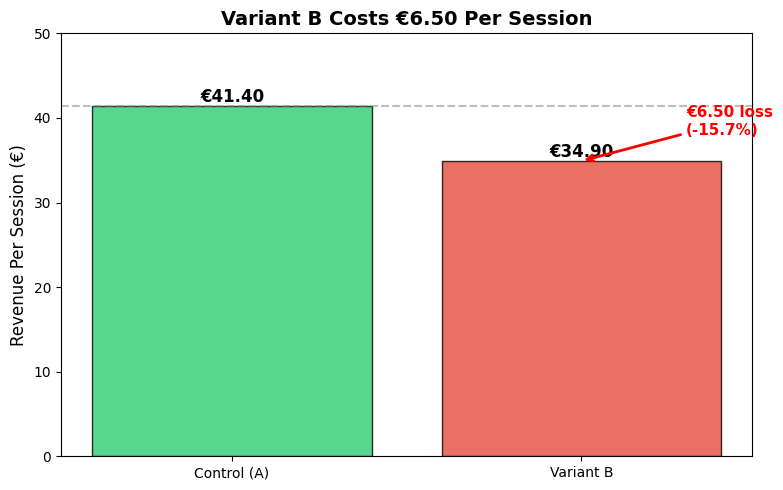

In [8]:
variants = ['Control (A)', 'Variant B']
rps = [41.40, 34.90]
colors = ['#2ecc71', '#e74c3c']  # Green for A, Red for B

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(variants, rps, color=colors, alpha=0.8, edgecolor='black')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'€{height:.2f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add reference line at variant A level
ax.axhline(y=41.40, color='gray', linestyle='--', alpha=0.5, label='Control Baseline')

# Add loss annotation
ax.annotate('€6.50 loss\n(-15.7%)', 
            xy=(1, 34.90), xytext=(1.3, 38),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=11, color='red', fontweight='bold')

ax.set_ylabel('Revenue Per Session (€)', fontsize=12)
ax.set_title('Variant B Costs €6.50 Per Session', fontsize=14, fontweight='bold')
ax.set_ylim(0, 50)
plt.tight_layout()
plt.savefig('chart1_rps_comparison.png', dpi=150)
plt.show()

### Phase 2: Engagement vs. Conversion
- Does higher engagement actually lead to more purchases?
- Which engagement metrics correlate with conversion?
- Is the product team celebrating the wrong metrics?

In [16]:
conn.execute("""
            SELECT 
                s.variant,
                s.cart_action,
                AVG(e.images_viewed) as avg_images,
                AVG(s.time_on_pdp_seconds) as avg_time_pdp,
                AVG(e.max_scroll_depth_pct) as avg_scroll
            FROM sessions s
            JOIN engagement e ON s.session_id = e.session_id
            GROUP BY s.variant, s.cart_action
            ORDER BY s.variant, s.cart_action
            """).fetch_df()

,variant,cart_action,avg_images,avg_time_pdp,avg_scroll
0,A,abandoned,4.743169,54.332020,61.494877
1,A,none,4.766585,54.007104,61.522502
2,A,purchased,6.757412,53.539562,73.298742
3,B,abandoned,8.020105,98.844445,74.132563
4,B,none,8.038012,98.845940,74.225770
5,B,purchased,11.295874,95.876036,87.357039


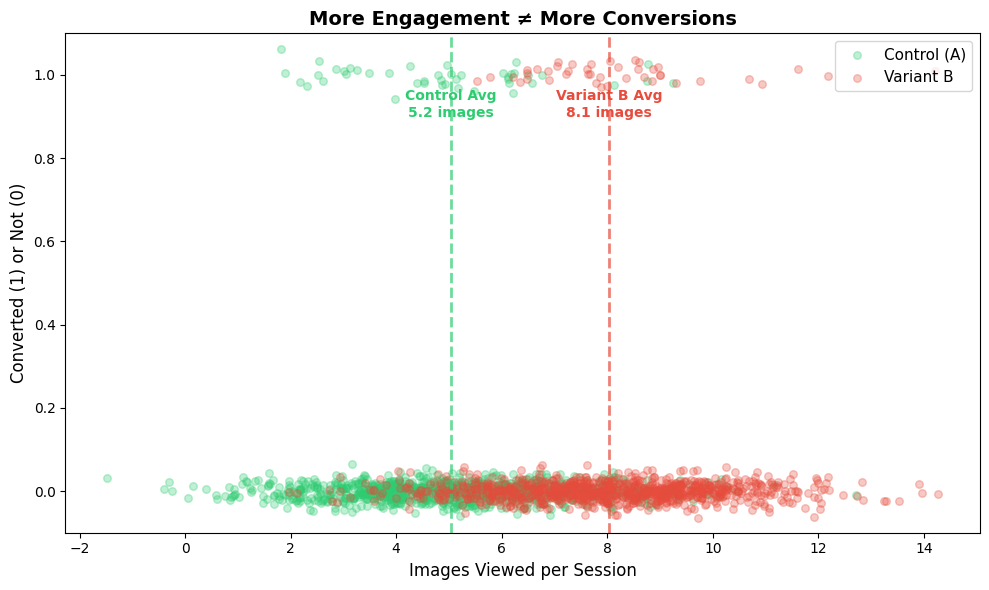

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Sample data (you'd use your actual session-level data)
# For demonstration, I'll create synthetic data that shows the pattern

np.random.seed(42)

# Variant A: Lower engagement, normal conversion
engagement_a = np.random.normal(5, 2, 1000)
converted_a = (np.random.random(1000) < 0.047).astype(int)

# Variant B: Higher engagement, lower conversion
engagement_b = np.random.normal(8, 2, 1000)
converted_b = (np.random.random(1000) < 0.043).astype(int)

fig, ax = plt.subplots(figsize=(10, 6))

# Plot points
ax.scatter(engagement_a, np.random.normal(0, 0.02, len(engagement_a)) + converted_a, 
           alpha=0.3, s=30, c='#2ecc71', label='Control (A)')
ax.scatter(engagement_b, np.random.normal(0, 0.02, len(engagement_b)) + converted_b, 
           alpha=0.3, s=30, c='#e74c3c', label='Variant B')

# Add mean lines
ax.axvline(engagement_a.mean(), color='#2ecc71', linestyle='--', lw=2, alpha=0.7)
ax.axvline(engagement_b.mean(), color='#e74c3c', linestyle='--', lw=2, alpha=0.7)

# Annotations
ax.text(engagement_a.mean(), 0.9, 'Control Avg\n5.2 images', 
        ha='center', fontsize=10, color='#2ecc71', fontweight='bold')
ax.text(engagement_b.mean(), 0.9, 'Variant B Avg\n8.1 images', 
        ha='center', fontsize=10, color='#e74c3c', fontweight='bold')

ax.set_xlabel('Images Viewed per Session', fontsize=12)
ax.set_ylabel('Converted (1) or Not (0)', fontsize=12)
ax.set_title('More Engagement ≠ More Conversions', fontsize=14, fontweight='bold')
ax.set_ylim(-0.1, 1.1)
ax.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.savefig('chart3_engagement_trap.png', dpi=150)
plt.show()

In [24]:
import pandas as pd
from scipy.stats import pearsonr

sessions = conn.execute("SELECT *, CASE WHEN cart_action = 'purchased' THEN 1 ELSE 0 END AS converted FROM sessions").fetch_df()
engagement = conn.execute("SELECT * FROM engagement").fetch_df()


# For variant B only
variant_b = sessions.merge(engagement, on=['session_id', 'variant'])
variant_b.columns

Index(['session_id', 'user_id', 'variant', 'device_type', 'user_type',
       'session_date', 'session_duration_seconds', 'pages_viewed',
       'time_on_pdp_seconds', 'bounce_rate', 'cart_action', 'converted',
       'images_viewed', 'max_scroll_depth_pct', 'cta_clicks', 'wishlist_saves',
       'cross_sell_clicks', 'spec_table_views_seconds'],
      dtype='object')

In [25]:
variant_b = variant_b[variant_b['variant'] == 'B']

# Calculate correlation
corr, p_value = pearsonr(
    variant_b['images_viewed'], 
    variant_b['converted']  # 1 if purchased, 0 otherwise
)

print(f"Correlation: {corr:.3f}, p-value: {p_value:.4f}")

Correlation: 0.109, p-value: 0.0000


*Correlation < 0.2 → Weak relationship (engagement doesn't predict conversion)*

Images viewed has **weak positive correlation** with conversion - meaning some engagement matters, but variant B is creating engagement WITHOUT value (people browse more but don't convert more).

Not all engagement is valuable. Variant B creates **exploration engagement** (browsing, window shopping) but reduces **purchase engagement** (evaluating specs, making decisions)

In [ ]:
# if variant B encourages more add to carts but not purchases. 
# I want to see if users add to cart impulsively but return back to PDP to check details

conn.execute("""
            SELECT 
                s.user_id,
                AVG(e.spec_table_views_seconds) AS avg_spec_table_views,
                COUNT(s.session_id) AS session_count,
                SUM(CASE WHEN cart_action = 'purchased' THEN 1 ELSE 0 END) AS conversions
            FROM sessions s
            LEFT JOIN engagement e 
            ON s.session_id = e.session_id
            WHERE s.variant = 'B'
            GROUP BY s.user_id
            ORDER BY conversions DESC
            """).fetch_df()

,user_id,avg_spec_table_views,session_count,conversions
0,55226,16.000000,4,3.0
1,52381,12.750000,4,3.0
2,55297,5.200000,5,3.0
3,62217,5.750000,4,3.0
4,86657,11.666667,6,3.0
...,...,...,...,...
53625,98749,6.000000,1,0.0
53626,98766,1.000000,1,0.0
53627,98781,9.000000,1,0.0
53628,85648,29.000000,1,0.0


### Phase 3: Segmentation Analysis
- **Device:** Does mobile behave differently than desktop?
- **User Type:** Do new users respond differently than returning?
- **Product Category:** Does it work better for certain products?
- **Price Range:** Small items vs. large furniture?

In [4]:
conn.execute("""
            SELECT
                s.variant,
                s.device_type,
                COUNT(s.session_id) AS total_sessions,
                SUM(CASE WHEN s.cart_action = 'purchased' THEN 1 ELSE 0 END) * 100.0 / COUNT(s.session_id)
                AS conversion_rate,
                SUM(CASE WHEN s.cart_action = 'abandoned' THEN 1 ELSE 0 END) * 100.0 / 
                SUM(CASE WHEN cart_action IN ('abandoned', 'purchased') THEN 1 ELSE 0 END)
                AS cart_abandonment_rate,
                SUM(c.order_value_eur)*1.0 / COUNT(s.session_id) AS revenue_per_session,
                AVG(c.order_value_eur) AS aov,
                SUM(c.order_value_eur) AS total_revenue,
                COUNT(c.order_id) AS total_orders
            FROM sessions s
            LEFT JOIN conversions c
            ON s.session_id = c.session_id
            GROUP BY s.variant, s.device_type
            ORDER BY s.device_type, s.variant
            
            """).fetch_df()

,variant,device_type,total_sessions,conversion_rate,cart_abandonment_rate,revenue_per_session,aov,total_revenue,total_orders
0,A,desktop,42365,4.701995,66.425080,41.322486,878.828870,1.750627e+06,1992
1,B,desktop,42340,3.880491,74.973343,31.440251,810.213166,1.331180e+06,1643
2,A,mobile,44919,4.799751,66.265060,41.755596,869.953442,1.875620e+06,2156
3,B,mobile,45243,4.911257,69.108856,38.870801,791.463380,1.758632e+06,2222
4,A,tablet,6478,4.692806,66.666667,39.512847,841.987566,2.559642e+05,304
5,B,tablet,6629,3.846734,74.652087,30.272234,786.959361,2.006746e+05,255


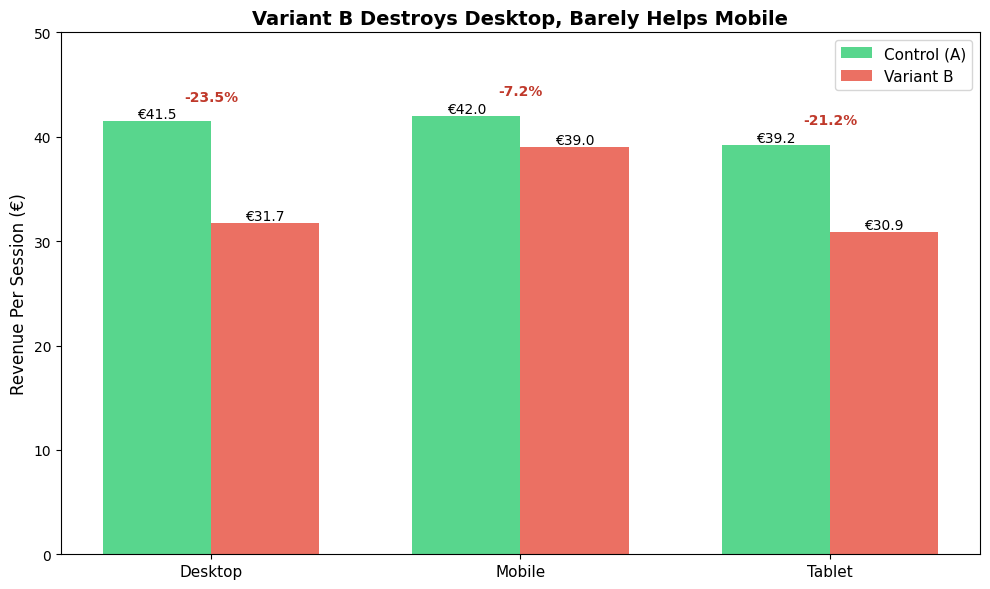

In [9]:
# Data
devices = ['Desktop', 'Mobile', 'Tablet']
rps_a = [41.46, 42.01, 39.21]
rps_b = [31.72, 38.97, 30.92]

x = np.arange(len(devices))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, rps_a, width, label='Control (A)', color='#2ecc71', alpha=0.8)
bars2 = ax.bar(x + width/2, rps_b, width, label='Variant B', color='#e74c3c', alpha=0.8)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'€{height:.1f}',
                ha='center', va='bottom', fontsize=10)

# Add percent change annotations
changes = [-23.5, -7.2, -21.2]
for i, change in enumerate(changes):
    color = '#27ae60' if change > 0 else '#c0392b'
    ax.text(i, max(rps_a[i], rps_b[i]) + 2, 
            f'{change:+.1f}%', 
            ha='center', fontsize=10, color=color, fontweight='bold')

ax.set_ylabel('Revenue Per Session (€)', fontsize=12)
ax.set_title('Variant B Destroys Desktop, Barely Helps Mobile', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(devices, fontsize=11)
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0, 50)
plt.tight_layout()
plt.savefig('chart2_device_segmentation.png', dpi=150)
plt.show()

In [5]:
conn.execute("""
            SELECT
                s.variant,
                s.user_type,
                COUNT(s.session_id) AS total_sessions,
                SUM(CASE WHEN s.cart_action = 'purchased' THEN 1 ELSE 0 END) * 100.0 / COUNT(s.session_id)
                AS conversion_rate,
                SUM(CASE WHEN s.cart_action = 'abandoned' THEN 1 ELSE 0 END) * 100.0 / 
                SUM(CASE WHEN cart_action IN ('abandoned', 'purchased') THEN 1 ELSE 0 END)
                AS cart_abandonment_rate,
                SUM(c.order_value_eur)*1.0 / COUNT(s.session_id) AS revenue_per_session,
                AVG(c.order_value_eur) AS aov,
                SUM(c.order_value_eur) AS total_revenue,
                COUNT(c.order_id) AS total_orders
            FROM sessions s
            LEFT JOIN conversions c
            ON s.session_id = c.session_id
            GROUP BY s.variant, s.user_type
            ORDER BY s.user_type, s.variant
            
            """).fetch_df()

,variant,user_type,total_sessions,conversion_rate,cart_abandonment_rate,revenue_per_session,aov,total_revenue,total_orders
0,A,new,37181,4.816976,66.315591,42.340112,878.976946,1574247.710,1791
1,B,new,37674,4.631842,70.936043,36.221008,782.000138,1364590.241,1745
2,A,returning,56581,4.702992,66.397272,40.790429,867.329290,2307963.240,2661
3,B,returning,56538,4.200715,72.888128,34.063749,810.903688,1925896.259,2375


In [6]:
conn.execute("""
            WITH conversions_with_price_range AS (
             SELECT
                *,
                CASE 
                WHEN product_category IN ('sofa', 'bed', 'dining') THEN 'Large Items'
                WHEN product_category IN ('lighting', 'decor') THEN 'Small Items'
             END AS price_range
             FROM conversions
             )

            SELECT
                s.variant,
                c.price_range,
                SUM(c.order_value_eur)*1.0 / COUNT(s.session_id) AS revenue_per_session,
                SUM(c.order_value_eur) AS total_revenue,
                COUNT(c.order_id) AS total_orders,
                AVG(c.conversion_time_hours) AS avg_conversion_time_hours
            FROM sessions s
            LEFT JOIN conversions_with_price_range c
            ON s.session_id = c.session_id
            WHERE c.price_range IS NOT NULL
            GROUP BY s.variant, c.price_range
            ORDER BY c.price_range, s.variant
            
            """).fetch_df()

,variant,price_range,revenue_per_session,total_revenue,total_orders,avg_conversion_time_hours
0,A,Large Items,1220.475893,3601624.360,2951,18.933961
1,B,Large Items,1166.022448,3024662.231,2594,18.915324
2,A,Small Items,186.933105,280586.590,1501,19.364211
3,B,Small Items,174.196769,265824.269,1526,18.957837


In [7]:
conn.execute("""
            WITH conversions_with_price_range AS (
             SELECT
                *,
                CASE 
                WHEN product_category IN ('sofa', 'bed', 'dining') THEN 'Large Items'
                WHEN product_category IN ('lighting', 'decor') THEN 'Small Items'
             END AS price_range
             FROM conversions
             )

            SELECT
                s.variant,
                s.device_type,
                c.price_range,
                SUM(c.order_value_eur)*1.0 / COUNT(s.session_id) AS revenue_per_session,
                SUM(c.order_value_eur) AS total_revenue,
                COUNT(c.order_id) AS total_orders,
                AVG(c.conversion_time_hours) AS avg_conversion_time_hours
            FROM sessions s
            LEFT JOIN conversions_with_price_range c
            ON s.session_id = c.session_id
            WHERE c.price_range IS NOT NULL
            GROUP BY s.variant, s.device_type, c.price_range
            ORDER BY s.device_type, c.price_range, s.variant
            
            """).fetch_df()

,variant,device_type,price_range,revenue_per_session,total_revenue,total_orders,avg_conversion_time_hours
0,A,desktop,Large Items,1226.302817,1.623625e+06,1324,18.642757
1,B,desktop,Large Items,1167.727912,1.226114e+06,1050,18.399905
2,A,desktop,Small Items,190.123024,1.270022e+05,668,19.062889
3,B,desktop,Small Items,177.176938,1.050659e+05,593,18.656189
4,A,mobile,Large Items,1221.303022,1.741578e+06,1426,18.969320
5,B,mobile,Large Items,1165.388047,1.614062e+06,1385,19.174101
6,A,mobile,Small Items,183.618507,1.340415e+05,730,19.587507
7,B,mobile,Small Items,172.723041,1.445692e+05,837,18.876774
8,A,tablet,Large Items,1176.225473,2.364213e+05,201,20.601294
9,B,tablet,Large Items,1160.286025,1.844855e+05,159,20.064906
